# Osatuletistega diferentsiaalvõrrandite lahendamine 2D ruumis  Finite Difference meetodi abil.

Kasutan kõigis järnevates simulatsioonides ruumihulgana lihtsat ruudukujulist 2D ruumihulka $R$.

$$R = \{(x, y) \mid 0 \leq x \leq 1, \, 0 \leq y \leq 1\}
$$

Alljärgnevalt inspireerituna S. J. Farlow'i õpikust "Partial Differential Equations for Scientists and Engineers" defineerin füüsikalised süsteemid ruumis $R$ kui osatuletistega DV-de ülesanded, koos mingi kindla rajatingimuse (BC - boundary condition) ja algtingimusega (IC - initial condition) ülesanded ruumi muutujate piirkonnas $(x, y) \in R$. Füüsikalistele süsteemidele tõetruuks jäädes on oluline defineerida algtingimused, kui mingid funktsioonid, mis on pidevad terve ruumihulga $R$ ulatuses, sh kindlasti ka rajakohtades ehk ruumihulga äärtes $\partial R$. Otsitav funktsioon vaadeldav kui kolmekohaline vektorsisendiga funktsioon, mille väljundiks on skalaarsuurus: 
$u = u(x, y, t)$.
Ruumihulga äär avaldub kujul: $$\partial R = \left\{ (x, y) \mid x = 0 \lor x = 1 \lor y = 0 \lor y = 1 \right\}$$

**I Difusioonivõrrand**  
$$
\begin{align}
    &\text{PDE:} \quad \frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad \alpha = 0.1 \quad (x, y) \in R,\quad t \in (0, T), \\
    &\text{BC:}\quad u(x, y, t) = 0,\quad (x, y) \in \partial R, \\
    &\text{IC:} \quad u(x, y, 0) = \phi(x, y),\quad (x, y) \in R.
\end{align}
$$


**II Lainevõrrand**
$$
\begin{align}
    &\text{PDE:}\quad \frac{\partial^2 u}{\partial t^2} = c^2(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}), \quad (x, y) \in R,\quad t \in (0, T), \quad c = 3e8, \\
    &\text{BC:}\quad u(x, y, t) = 0,\quad (x, y) \in \partial R, \\
    &\text{IC:} \quad u(x, y, 0) = \phi(x, y),\quad (x, y) \in R.
\end{align}
$$

**III Lainevõrrand forsseeriva teguriga (uuritav resonaatori süsteem)**\
Forsseeriv tegur mõjub ainult mingisugusele kesksele punktile - näiteks mingi võnkuv punktlaeng, mille võnkumine tekitab elektromagnetvälja üle terve ruumipiirkonna $R$.
$$
\begin{align}
    &\text{PDE:}\quad \frac{\partial^2 u}{\partial t^2} = c^2(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}) + f(x, y, t), \quad (x, y) \in R,\quad t \in (0, T),\quad  c = 3e8, \\
    &f(x, y, t) = \delta_\text{tsenter} \phi(t),\quad t \in [0, T] \\
    &\delta_\text{tsenter} = \begin{cases}
    1, & \text{kui}\quad x = 0.5 \;\text{ja} \; y = 0.5 \\
    0 & \text{kõigi teiste koordinaatide puhul.}
    \end{cases}\\
    &\text{BC:} \quad u(x, y, t) = 0,\quad (x, y) \in \partial R, \\
    &\text{IC:} \quad u(x, y, 0) = 0, \quad (x, y) \in R. \\
\end{align}
$$

**IV Difusioonivõrrand keerulisema rajatingimusega**\
Valin huvitava ääretingimuse. Jäädes tõetruuks füüsikale peab algtingimuse funktsioon sobituma ääretingimustega ehk olema määratud ja pidev (või ligilähedaselt pidev) äärtes.  
$$
\begin{align}
    &\text{PDE:} \quad \frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad \alpha = 0.1 \quad (x, y) \in R,\quad t \in (0, T), \\
    &\text{BC:} \quad(x, y) \in \partial R \\
    &u(x=0, y, t) = T_0, \\
    &u(x=1, y, t) = T_1, \\
    &u(x, y=0, t) = T_0 + (T_1 - T_0)x, \\
    &u(x, y=1, t) = T_0 + (T_1 - T_0)x, \\
    &\text{IC:} \quad u(x, y, 0) = \phi(x, y),\quad (x, y) \in R.
\end{align}
$$

**FINITE DIFFERENCE MEETODI TULETISTE ARVUTAMISEL**
 
(Inspireeritud blogipostitusest: 
https://janmr.com/blog/2024/05/finite-difference-discretization-of-2d-laplace )
Tuletiste diskretatsioonid on avaldatud tuletise piirväärtusliku definitsiooni ja Lagrange'i keskväärtusteoreemi kaudu.
Diskreetsel kujul avaldub esimene osatuletis aja järgi järgnevalt:
$$\frac{\partial u(x, y, t)}{\partial t} \approx \frac{u(x, y, t + \Delta t) - u(x, y, t)}{\Delta t},$$
ning teine tuletis aja järgi avaldub kujul:
$$\frac{\partial^2 u(x, y, t)}{\partial^2 t} \approx \frac{u(x, y, t - \Delta t) -2u(x, y, t) + u(x, y, t + \Delta t)}{(\Delta t)^2}.$$
Teine ruumiline osatuletis ruumikoordinaatide järgi ehk Laplace'i operaator 2D ruumis avaldub analoogselt kujul:
$$\nabla^2 u(x, y, t) = \frac{\partial^2 u(x, y, t)}{\partial x^2} + \frac{\partial^2 u(x, y, t)}{\partial y^2} \approx \\ \approx \frac{u(x - \Delta x, y, t) -2u(x, y, t) + u(x + \Delta x, y, t)}{(\Delta x)^2} + \frac{u(x, y - \Delta y, t) -2u(x, y, t) + u(x, y + \Delta y, t)}{(\Delta y)^2}
$$

Alljärgnevas koodis valin simulatsiooni ristküliku ühe dimensiooni ruumipunktide arvuks lihtsustuse huvides $N = M = 1000$, nii, et moodustub $M\times N$ võre (üldistades jätan sisse edaspidi ka M-i), mis hoiab $u(x, y, t)$ väärtusi. Ruumilise diskretatsiooni miinimummääraks saab minu simulatsioonis $\Delta x =  \Delta y = h = 1 / 1000$. Diskretatsiooni eesmärgil viin välja funktsiooni kujule $u(x, y, t) = u(i h,j h, k \Delta t) = u_{ij}^{[k]}$, kus i, j ja k on vastavalt xy-koordinaatide ja ajasammu indeksid. Seega teades, et $\Delta x =  \Delta y = h$, saab eelneva avaldise kokku summerida ja viia kujule:

$$
\nabla^2 u_{ij}^{[k]} \approx \frac{u_{(i-1)j}^{[k]}  + u_{(i+1)j}^{[k]}+ u_{i(j-1)}^{[k]}+ u_{i(j+1)}^{[k]} - 4u_{ij}^{[k]}}{h^2}$$

Olgu meil ruumiliselt diskretiseeritud andmepunktidega maatriks $\mathbf{U}^{[k]} \in \mathbb{R}^{M\times N}$, mille iga element on välja $u_{ij}^{[k]}$ väärtus ajahetkel $t = k \Delta t$. 1D Laplace'i diskreetsel rakendamisel ruumilisel andmevektoril $\mathbf{u}^{[k]} \in \mathbb{R}^{q}$ kasutatakse tridiagonaalset maatriksit $\mathbf{L}_q = \mathbb{R}^{q\times q}$, mille diagonaalil on $\frac{-2}{h^2}$ ja mõlemal kõrvaldiagonaalil on $\frac{1}{h^2}$. Seega ruumilise andmevektori teine osatuletis avaldub kujul $\nabla^2 \mathbf{u}^{[k]} \approx L_k \mathbf{u}^{[k]}$ ehk ühtlasi rakendub teine ruumiline osatuletist õigetele indeksitele piki andmevektorit (veeruvektor) maatrikskorrutise läbi ilma tsükleid kasutamata. Rakendades sama metoodikat 2D andmemaatriksi $\mathbf{U}^{[k]}$ jaoks tuleb rakendada maatriksit $\mathbf{L}_m$ maatriksi $\mathbf{U}^{[k]}$ veeruvektoritel pikkusega m ja maatriksit $\mathbf{L}_n$ maatriksi $\mathbf{U}^{[k]}$ reavektoritel ning saadud tulemused kokku liita.
Algebralisel kujul on 2D Laplace'i operaator avalduv kujul $ \nabla^2 \mathbf{U}^{[k]} \approx \mathbf{L}_m\mathbf{U}^{[k]} + (\mathbf{L}_n(\mathbf{U}^{[k]})^T)^T = \mathbf{L}_m\mathbf{U}^{[k]} + \mathbf{U}^{[k]}\mathbf{L}_n^T$ (sümmeetrilise maatriksi puhul teatavasti $\mathbf{L}_n^T = \mathbf{L}_n$ ). See on ühtlasi ka üldine valem taolise "5-punkti šablooni" (5-point stencil) rakendamiseks kahe maatrikskorrutise summana. Sümmeetrilise maatriksi puhul ei pea viima Ilmneb, et see viimane tehe nõuab umbes $12mn$ ujukoma arvutust, kui kasutatakse hõredaid maatrikseid ning on olemas veel efektiivsem meetod, mis rakendab Kröeneckeri korrutist ja summat, et $10mn$. Esialgu kasutan lihtsuse huvides seda veidi ebaefektiivsemat meetodit.

Taoliste aja simulatsioonide puhul on numbrilise stabiilsuse tagamiseks üldlevinud tava valida sellised ajalised diskretatsioonid $\Delta t$, mis rahuldavad Courant-Friedrichs-Lewy tingimusi, millr olen valinud difusiooni ja lainevõrrandi jaoks vastavalt: $$\frac{\alpha \Delta t}{(\Delta x)^2} \leq 1/2$$ ja $$ \frac{c \Delta t}{\Delta x} \leq 1.$$

**VÕRRANDI LAHENDAMINE**

Diskretiseeritult on difusiooni ja lainevõrrand Laplace'i operaatoreid ilmutamata kujudel:

$$
\frac{u_{ij}^{[k+1]}  - u_{ij}^{[k]}}{\Delta t} = \alpha\nabla^2 u_{ij}^{[k]},$$

$$
\frac{u_{ij}^{[k-1]}  + u_{ij}^{[k+1]} - 2u_{ij}^{[k]}}{\Delta t^2} = c^2\nabla^2 u_{ij}^{[k]}.$$

Teades xy-koordinaatidel indeksitega $i, j$ ja selle ümbruses (neljas punktis) olevat välja väärtust ajahetkedel $k\Delta t$ ja $(k-1) \Delta t$, saame avaldada välja väärtuse ajahetkel $(k+1)\Delta t$ ehk $u_{ij}^{[k+1]}$ ühtlasi lahendades võrrandi. Lahendid avalduvad difusiooni ja lainevõrrandi jaoks kujul:

$$
u_{ij}^{[k+1]} = \alpha \Delta t  \nabla^2u_{ij}^{[k]} + u_{ij}^{[k]},$$
$$
u_{ij}^{[k+1]} = c^2 \Delta t^2 \nabla^2 u_{ij}^{[k]} - u_{ij}^{[k-1]} + 2u_{ij}^{[k]}.$$

Maatrikskujudel on rakendades eelnevalt leitud Laplace'i operaatorit need lahendid vastavalt:

$$\mathbf{U}^{[k+1]} = \alpha \Delta t (\mathbf{L}_m\mathbf{U}^{[k]} + \mathbf{U}^{[k]}\mathbf{L}_n^T) + \mathbf{U}^{[k]}, $$

$$
\mathbf{U}^{[k+1]} = c^2 \Delta t^2 (\mathbf{L}_m\mathbf{U}^{[k]} + \mathbf{U}^{[k]}\mathbf{L}_n^T) - \mathbf{U}^{[k-1]} + 2\mathbf{U}^{[k]}.$$

In [3]:
# kasutan kiirendatud Numpy versiooni jax.numpy, mida saab ühildada ka CUDA tuumadega
# juba CPU-l on jax.numpy ca 2 korda kiirem
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

In [4]:
n = 1000
c = 3e8
alpha = 0.1
x, y = jnp.linspace(0, 1, n), jnp.linspace(0, 1, n)
h = x[1] - x[0]
xv, yv = jnp.meshgrid(x, y)
#valin ajasammud vastavalt CFL tingimustele
dt1 = 0.5*h / c
dt2 = 0.25*(h**2) / alpha

dt1, dt2

(Array(1.668335e-12, dtype=float32), Array(2.5050074e-06, dtype=float32))

In [5]:
L_n = (-2*jnp.diag(jnp.ones(n)) + jnp.diag(jnp.ones(n-1), 1) + jnp.diag(jnp.ones(n-1), -1)) * (1/h)**2
print(L_n)

[[-1996002.   998001.        0. ...        0.        0.        0.]
 [  998001. -1996002.   998001. ...        0.        0.        0.]
 [       0.   998001. -1996002. ...        0.        0.        0.]
 ...
 [       0.        0.        0. ... -1996002.   998001.        0.]
 [       0.        0.        0. ...   998001. -1996002.   998001.]
 [       0.        0.        0. ...        0.   998001. -1996002.]]


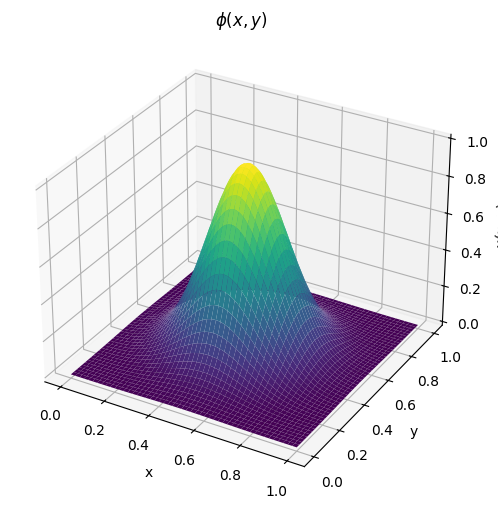

In [6]:
phi_1 = jnp.exp(-20*((xv - jnp.ones_like(xv)*0.5)**2 + (yv - jnp.ones_like(xv)*0.5)**2))
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, phi_1, cmap="viridis")
ax.set_title(r"$\phi(x, y)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x, y)")
plt.show()

#rakendan algtingimusi
phi_1 = phi_1.at[0, :].set(jnp.zeros(phi_1.shape[1]))
phi_1 = phi_1.at[-1, :].set(jnp.zeros(phi_1.shape[1]))
phi_1 = phi_1.at[:,0].set(jnp.zeros(phi_1.shape[0]))
phi_1 = phi_1.at[:,-1].set(jnp.zeros(phi_1.shape[0]))


Kasutan `scipy.sparse` maatriksi hõrendamise vahendit `csr_matrix`.

In [7]:
sparse_L_n_no_boundaries = csr_matrix(L_n[1:-1,1:-1])
sparse_L_n = csr_matrix(L_n)
result = sparse_L_n @phi_1 + phi_1@sparse_L_n.T

In [8]:
sparse_L_n.shape, L_n.size, sparse_L_n.size

((1000, 1000), 1000000, 2998)

In [9]:
res = L_n@phi_1 + phi_1@L_n.T
res

Array([[ 0.0000000e+00,  4.7158272e+01,  4.8108986e+01, ...,
         4.8108986e+01,  4.7158272e+01,  0.0000000e+00],
       [ 4.7158272e+01, -9.2415115e+01, -4.7121815e+01, ...,
        -4.7121819e+01, -9.2415115e+01,  4.7158272e+01],
       [ 4.8108986e+01, -4.7121815e+01,  3.4991425e-02, ...,
         3.4988403e-02, -4.7121819e+01,  4.8108986e+01],
       ...,
       [ 4.8108986e+01, -4.7121815e+01,  3.4988936e-02, ...,
         3.4988403e-02, -4.7121819e+01,  4.8108986e+01],
       [ 4.7158272e+01, -9.2415115e+01, -4.7121811e+01, ...,
        -4.7121819e+01, -9.2415115e+01,  4.7158272e+01],
       [ 0.0000000e+00,  4.7158272e+01,  4.8108986e+01, ...,
         4.8108986e+01,  4.7158272e+01,  0.0000000e+00]], dtype=float32)

**Difusioonivõrrandi lahendi defineerimine koodis**

Rajatingimuseks on difusioon/soojavõrrandi puhul $u(x, y, t) = 0$ kogu $\partial$ R ulatuses. Rajatingimuste sätestamise välja jätmine iteratsiooni funktsioonist tegi komputatsiooni keskeltläbi 1.5 korda kiiremaks, aga teeb kogu arvutuse ilmselt ebatäpsemaks, sest paratamatult difuseerib difusiooni/soojusprofiil või levib laine äärtesse.

In [10]:
def D2(U):
    return (sparse_L_n @U + U@sparse_L_n.T)

def heat_eq(U, t, dt):
    U_next = jnp.zeros_like(U)
    U_next= alpha * dt* (sparse_L_n @U + U@sparse_L_n.T) + U
    #rajatingimused
    U_next = U_next.at[0, :].set(jnp.zeros(n))
    U_next = U_next.at[-1, :].set(jnp.zeros(n))
    U_next = U_next.at[:,0].set(jnp.zeros(n))
    U_next = U_next.at[:,-1].set(jnp.zeros(n))
    t += dt
    return U_next, t

**ALGTINGIMUSE FUNKTSIOONI $\phi(x, y)$ DEFINEERIMINE I JA II ÜLESANDE JAOKS**

Rajatingimuse $u(x, y, t) = 0 , (x, y) \in \partial R$ puhul rakendan ruumis $R \setminus \partial R$ algtingimuse funktsiooni:
$$  
\phi(x, y) = \exp(-200((x - 0.5)^2 + (y - 0.5)^2)),
    $$
mille puhul on tegu ruumilise Gaussi jaotusega, mille väärtuste osakaal on suurim ruumi $R$ tsentri juures selliselt, et see on enam-vähem pidev äärte juures (st väärtused eelviimastel koordinaatidel on ligikaudu 0).

**I ÜLESANNE: DIFUSIOONI VÕRRANDI LAHENDAMINE**

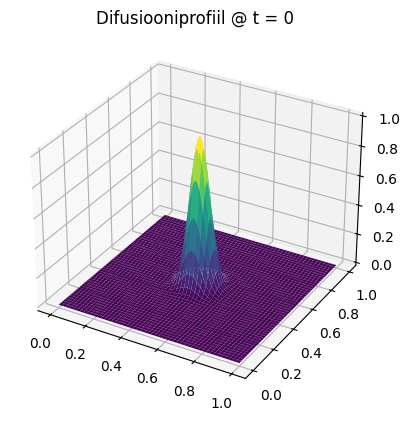

In [11]:
#algtingimus koos forsseeritud rajatingimustega
phi_0 = jnp.exp(-200*((xv - jnp.ones_like(xv)*0.5)**2 + (yv - jnp.ones_like(xv)*0.5)**2))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, phi_0, cmap="viridis")
#rajatingimuste kehtestamine ehk u = 0 at deltaR
phi_0 = phi_0.at[0, :].set(jnp.zeros(n))
phi_0 = phi_0.at[-1, :].set(jnp.zeros(n))
phi_0 = phi_0.at[:,0].set(jnp.zeros(n))
phi_0 = phi_0.at[:,-1].set(jnp.zeros(n))

plt.title("Difusiooniprofiil @ t = 0")
plt.show()

In [12]:
jnp.abs(phi_0[0]).max(), jnp.abs(phi_0[-1]).max(),jnp.abs(phi_0[:,0]).max(),jnp.abs(phi_0[:,-1]).max(),

(Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32),
 Array(0., dtype=float32))

In [13]:
time = 0
nextt, time = heat_eq(phi_0, time, dt2)
#nextt[n//2][n//2], phi_1[n//2][n//2]

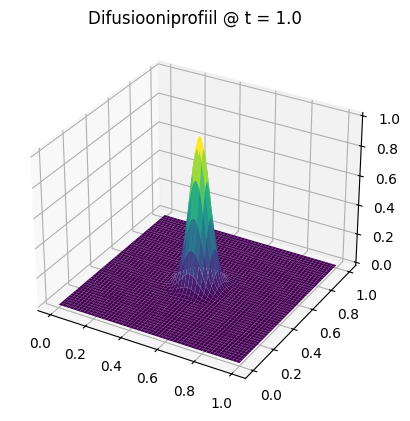

In [14]:
time = 0
U_k, time = heat_eq(phi_0, time, dt2)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U_k, cmap="viridis")
plt.title(f"Difusiooniprofiil @ t = {time//dt2}")
plt.show()

In [15]:
import jax
print(jax.devices())

[CpuDevice(id=0)]


In [16]:
time = 0
U_100 = phi_0
for r in range(100):
    U_100, time = heat_eq(U_100, t = time,dt=dt2)

Viimane arvutus (100 ajasammu) `scipy` hõrendatud maatriksitega aega 1.4 sekundit ja mittehõrendatud maatriksitega aega 1.9 sekundit.

In [17]:
time = 0
U_5000 = phi_0
for r in range(5000):
    U_5000, time = heat_eq(U_5000, t = time,dt=dt2)

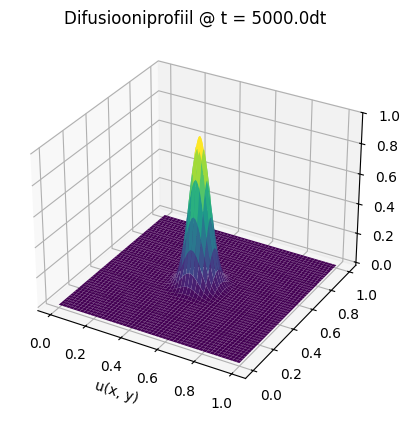

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U_100, cmap="viridis")
plt.title(f"Difusiooniprofiil @ t = {time//dt2}dt")
ax.set_xlabel("x")
ax.set_xlabel("y")
ax.set_xlabel("u(x, y)")
plt.show()

Minu CPU-l võtab viimane arvutus (5000 ajasammu difusiooni esialgu koos rajatingimustega taasmääramisega) võttis aega 132 sekundit tavalise Numpy-ga ja JAX Numpy-ga 63 sekundit. 

In [19]:
time = 0
U_500 = phi_0
for r in range(500):
    U_500, time = heat_eq(U_500, t = time,dt=dt2)

In [20]:
time = 0
U_1000 = phi_0
for r in range(1000):
    U_1000, time = heat_eq(U_1000, t = time,dt=dt2)

In [21]:
time = 0
U_2000 = phi_0
for r in range(2000):
    U_2000, time = heat_eq(U_2000, t = time,dt=dt2)

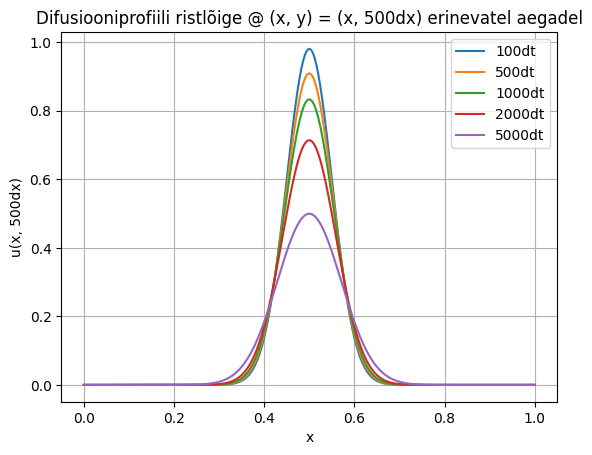

In [22]:
plt.title("Difusiooniprofiili ristlõige @ (x, y) = (x, 500dx) erinevatel aegadel")
plt.ylabel("u(x, 500dx)")
plt.xlabel("x")

plt.plot(xv[0], U_100[n//2], label = "100dt")
plt.plot(xv[0], U_500[n//2], label = "500dt")
plt.plot(xv[0], U_1000[n//2], label = "1000dt")
plt.plot(xv[0], U_2000[n//2], label = "2000dt")
plt.plot(xv[0], U_5000[n//2], label = "5000dt")
plt.grid()
plt.legend()
plt.show()

**II ÜLESANNE: LAINEVÕRRANDI LAHENDAMINE**\
Teise ajatuletise esinemisest tulenevalt esineb lainevõrrandi lahendis 
$$
\mathbf{U}^{[k+1]} = c^2 \Delta t^2 (\mathbf{L}_m\mathbf{U}^{[k]} + \mathbf{U}^{[k]}\mathbf{L}_n^T) - \mathbf{U}^{[k-1]} + 2\mathbf{U}^{[k]}$$
ka andmemaatriksi väärtus ajasammul k-1, seega on oluline terve salvestada iga iteratsioonisammu puhul ka eelmise sammu olek. Kuna mul on ainult algtingimuse funktsioon $u(x, y, t = 0) = \phi(x, y)$ ja pole infot -1 ajasammu oleku kohta, siis simuleerimise algul eeldan, et need olekud on identsed ehk $\mathbf{U}^{[0]} = \mathbf{U}^{[-1]} = \mathbf{\Phi}$, kus $ \mathbf{\Phi} \in \mathbb{R}^{M \times N}$ on algtingimuse funktsiooni andmemaatriks.     

In [23]:
U2_0 = phi_0.copy()
U2_0_prev = U2_0.copy()
#phi_0[0] == jnp.zeros(n)

**Lainevõrrandi lahendi defineerimine koodis**

In [24]:
def wave_eq(U, U_prev, t, dt):
    U_next = c**2 * dt**2 * D2(U) + 2*U - U_prev
    #rajatingimused
    U_next = U_next.at[0, :].set(jnp.zeros(n))
    U_next = U_next.at[-1, :].set(jnp.zeros(n))
    U_next = U_next.at[:,0].set(jnp.zeros(n))
    U_next = U_next.at[:,-1].set(jnp.zeros(n))
    t += dt
    return U_next, U, t

In [25]:

time = 0
Uw_1, Uw_1prev, time = wave_eq(U2_0,U2_0_prev, t = time, dt = dt1)

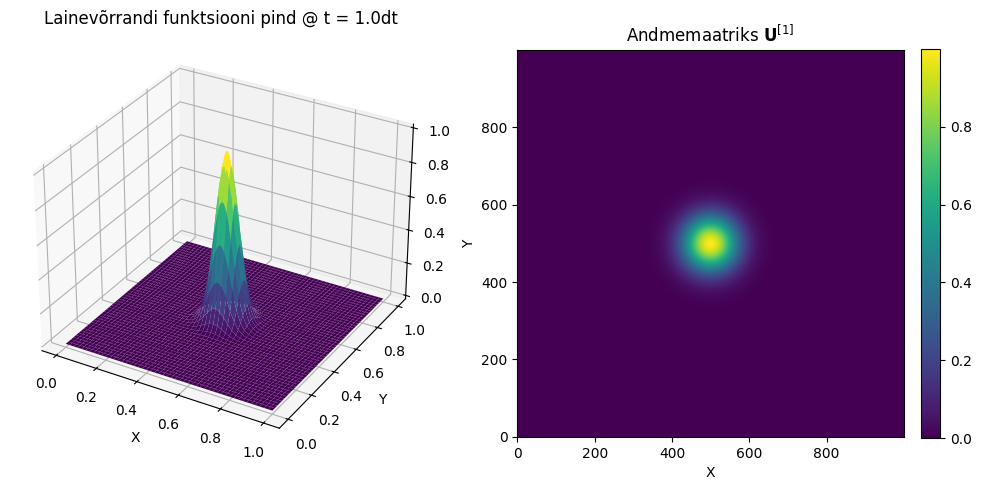

In [26]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, Uw_1, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = {time//dt1}dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(Uw_1, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[1]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [27]:
time = 0
U2_100 = U2_0.copy()
U2_100prev = U2_100.copy()
for i in range(100):
    U2_100, U2_100prev, time = wave_eq(U2_100, U2_100prev, t = time, dt = dt1)

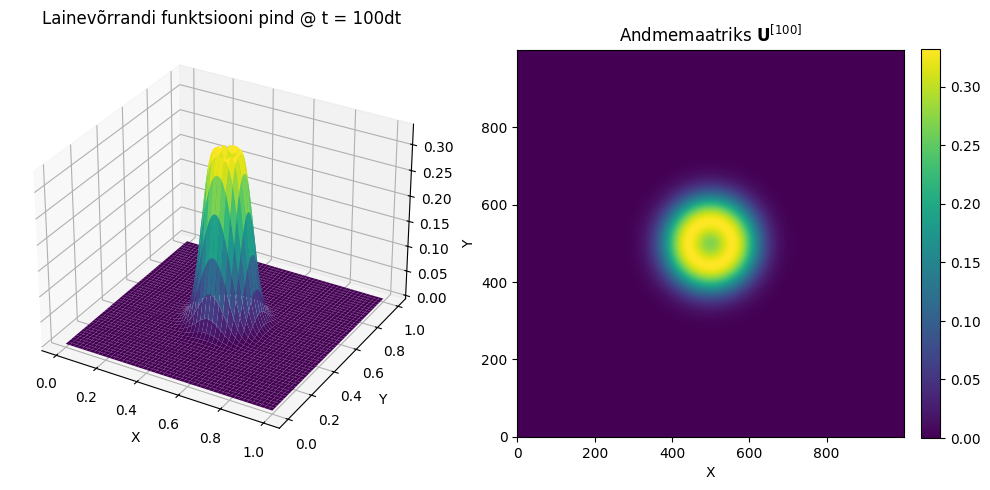

In [28]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_100, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = {100}dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_100, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[100]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [29]:
time = 0
U2_200 = U2_0.copy()
U2_200prev = U2_200.copy()
for i in range(200):
    U2_200, U2_200prev, time = wave_eq(U2_200, U2_200prev, t = time, dt = dt1)
time//dt1

Array(199., dtype=float32)

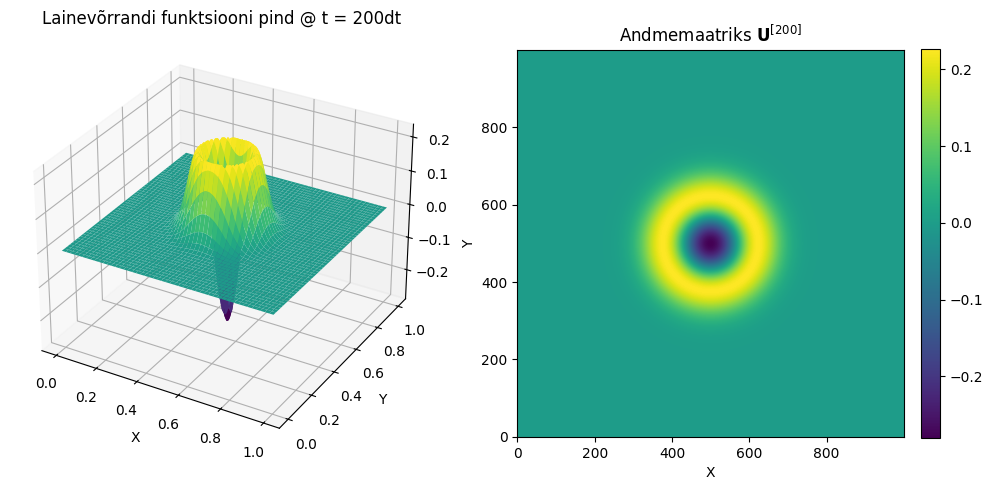

In [30]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_200, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 200dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_200, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[200]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [31]:
U2_400 = U2_200.copy()
U2_400prev = U2_200prev.copy()
for i in range(200):
    U2_400, U2_400prev, time = wave_eq(U2_400, U2_400prev, t = time, dt = dt1)

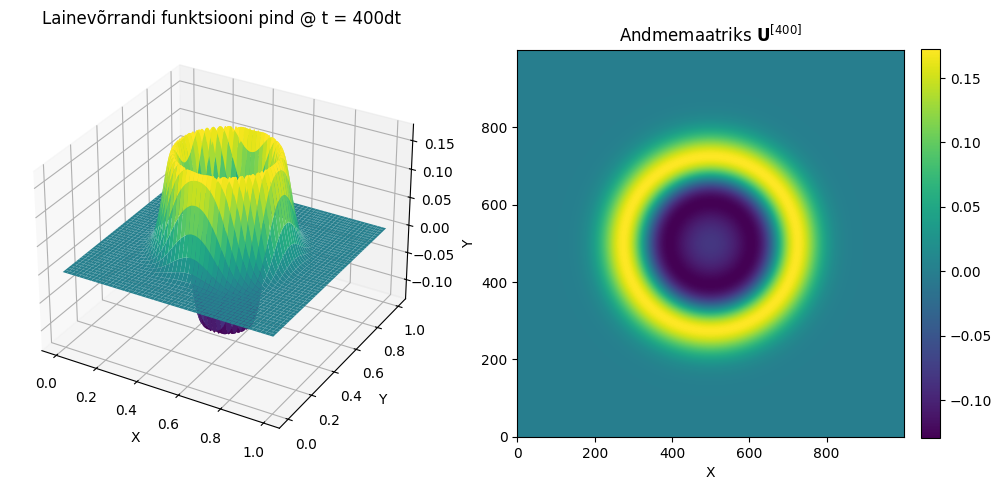

In [32]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_400, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 400dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_400, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[400]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [33]:
U2_600 = U2_400.copy()
U2_600prev = U2_400prev.copy()
for i in range(200):
    U2_600, U2_600prev, time = wave_eq(U2_600, U2_600prev, t = time, dt = dt1)

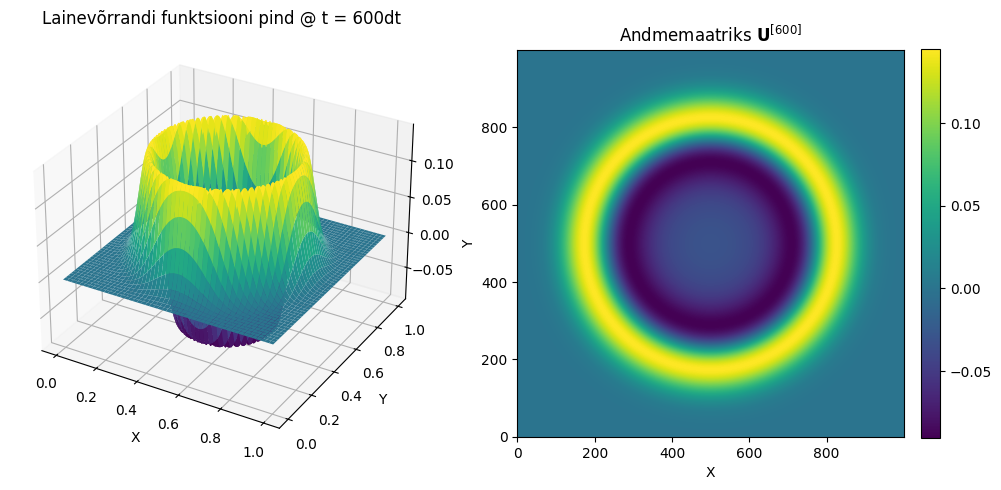

In [34]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_600, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 600dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_600, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[600]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [35]:
U2_800 = U2_600.copy()
U2_800prev = U2_600prev.copy()
for i in range(200):
    U2_800, U2_800prev, time = wave_eq(U2_800, U2_800prev, t = time, dt = dt1)

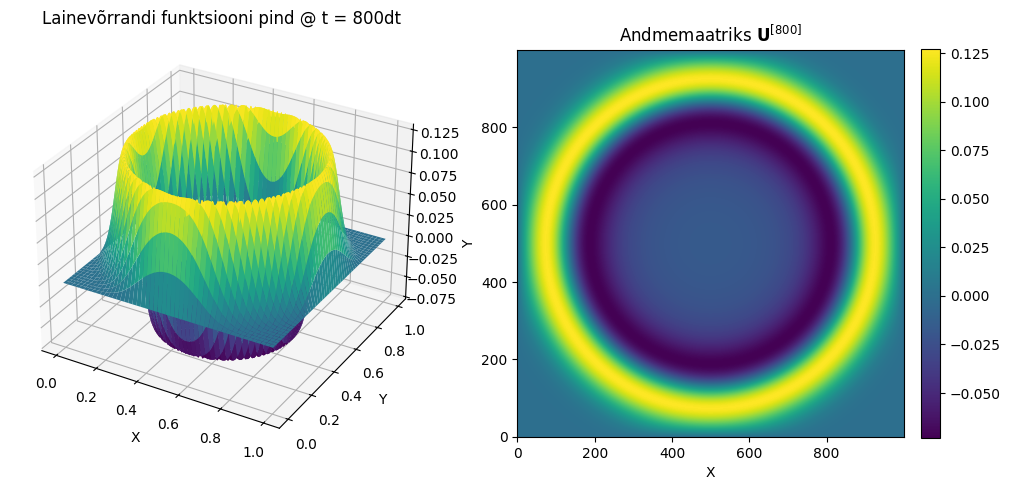

In [36]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_800, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 800dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_800, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[800]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [37]:
U2_1000 = U2_800.copy()
U2_1000prev = U2_800prev.copy()
for i in range(200):
    U2_1000, U2_1000prev, time = wave_eq(U2_1000, U2_1000prev, t = time, dt = dt1)

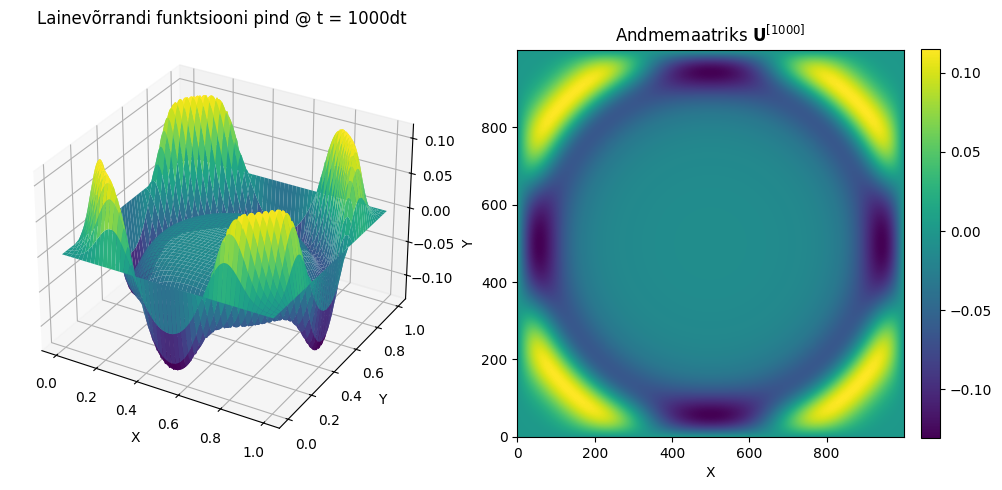

Array(999., dtype=float32)

In [38]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_1000, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 1000dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_1000, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[1000]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()
time//dt1

In [39]:
U2_2000 = U2_1000.copy()
U2_2000prev = U2_1000prev.copy()
for i in range(1000):
    U2_2000, U2_2000prev, time = wave_eq(U2_2000, U2_2000prev, t = time, dt = dt1)
time //dt1

Array(2000., dtype=float32)

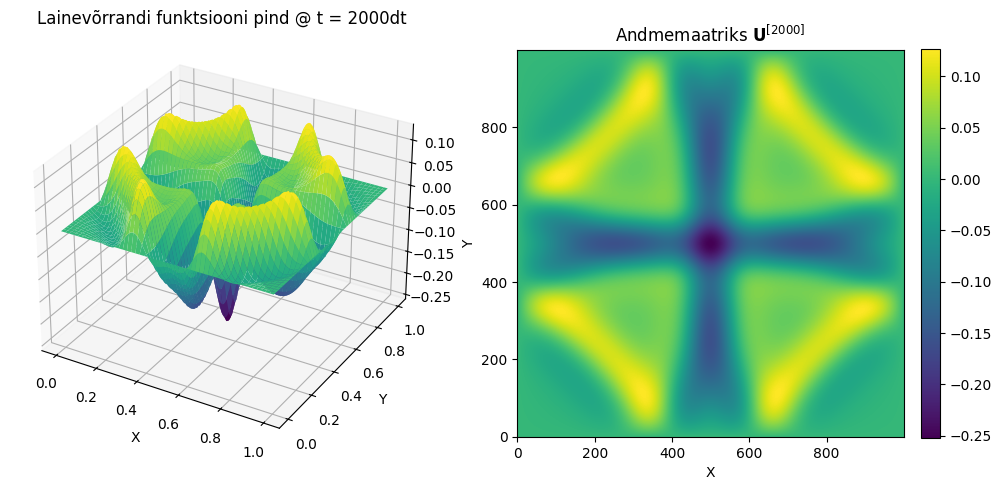

In [40]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(xv, yv, U2_2000, cmap="viridis")
ax1.set_title(f"Lainevõrrandi funktsiooni pind @ t = 2000dt")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

ax2 = fig.add_subplot(gs[1])
img = ax2.imshow(U2_2000, cmap="viridis", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[2000]}$")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

In [41]:
U2_4000 = U2_2000.copy()
U2_4000prev = U2_2000prev.copy()
for i in range(2000):
    U2_4000, U2_4000prev, time = wave_eq(U2_4000, U2_4000prev, t = time, dt = dt1)

time//dt1

Array(4000., dtype=float32)

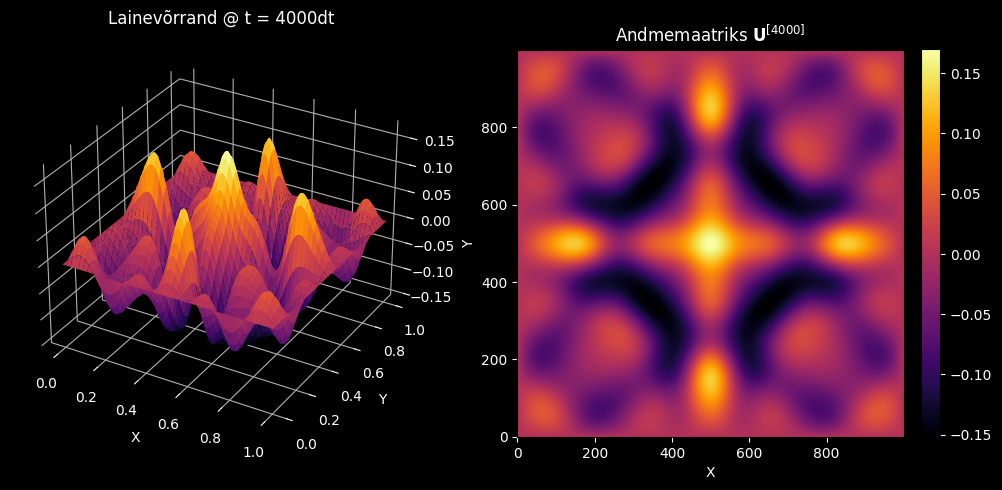

In [42]:
fig = plt.figure(figsize=(12, 6), facecolor='black')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d', facecolor='black')
ax1.plot_surface(xv, yv, U2_4000, cmap="inferno")
ax1.set_title(f"Lainevõrrand @ t = 4000dt", color='white')
ax1.set_xlabel("X", color='white')
ax1.set_ylabel("Y", color='white')
ax1.tick_params(colors='white')

ax1.xaxis.set_pane_color((0, 0, 0, 0))
ax1.yaxis.set_pane_color((0, 0, 0, 0))
ax1.zaxis.set_pane_color((0, 0, 0, 0))

ax2 = fig.add_subplot(gs[1], facecolor='black') 
img = ax2.imshow(U2_4000, cmap="inferno", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[4000]}$", color='white')
ax2.set_xlabel("X", color='white')
ax2.set_ylabel("Y", color='white')
ax2.tick_params(colors='white')
cbar = fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
plt.show()


In [43]:
U2_10000 = U2_4000.copy()
U2_10000prev = U2_4000prev.copy()
for i in range(6000):
    U2_10000, U2_10000prev, time = wave_eq(U2_10000, U2_10000prev, t = time, dt = dt1)

In [44]:
time//dt1

Array(9999., dtype=float32)

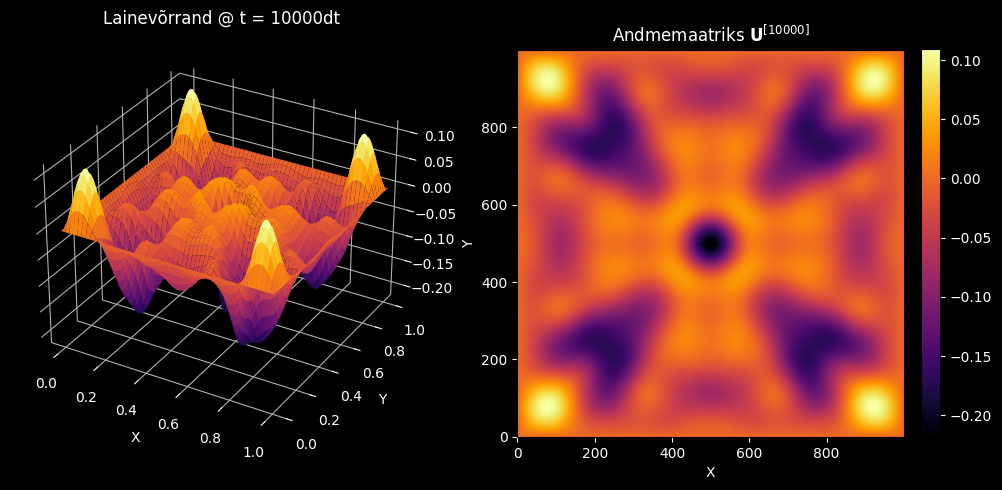

In [45]:
fig = plt.figure(figsize=(12, 6), facecolor='black')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d', facecolor='black')
ax1.plot_surface(xv, yv, U2_10000, cmap="inferno")
ax1.set_title(f"Lainevõrrand @ t = 10000dt", color='white')
ax1.set_xlabel("X", color='white')
ax1.set_ylabel("Y", color='white')
ax1.tick_params(colors='white')

ax1.xaxis.set_pane_color((0, 0, 0, 0))
ax1.yaxis.set_pane_color((0, 0, 0, 0))
ax1.zaxis.set_pane_color((0, 0, 0, 0))

ax2 = fig.add_subplot(gs[1], facecolor='black') 
img = ax2.imshow(U2_10000, cmap="inferno", origin="lower")
ax2.set_title(r"Andmemaatriks $\mathbf{U}^{[10000]}$", color='white')
ax2.set_xlabel("X", color='white')
ax2.set_ylabel("Y", color='white')
ax2.tick_params(colors='white')

cbar = fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.show()


In [46]:
U2_20000 = U2_10000.copy()
U2_20000prev = U2_10000prev.copy()
for i in range(10000):
    U2_20000, U2_20000prev, time = wave_eq(U2_20000, U2_20000prev, t = time, dt = dt1)

In [47]:
time//dt1

Array(19999., dtype=float32)

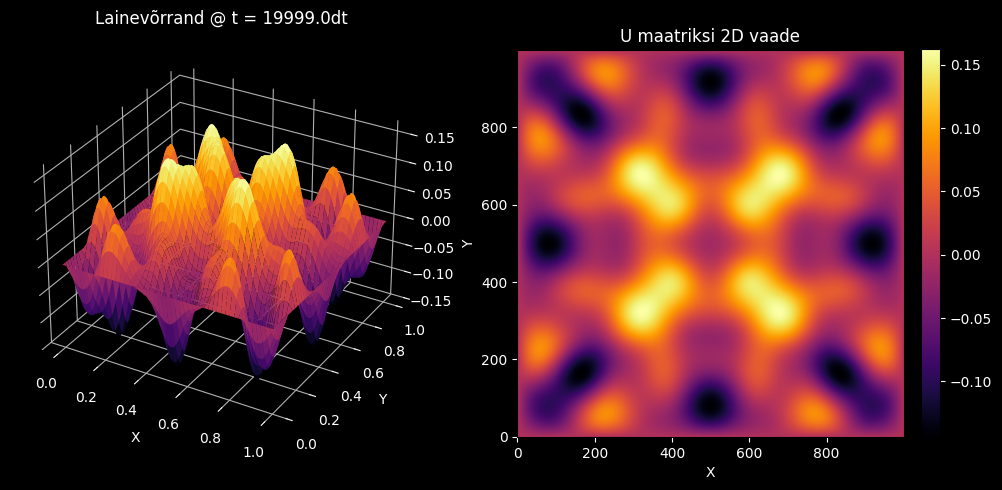

In [48]:
fig = plt.figure(figsize=(12, 6), facecolor='black')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0], projection='3d', facecolor='black')
ax1.plot_surface(xv, yv, U2_20000, cmap="inferno")
ax1.set_title(f"Lainevõrrand @ t = {time//dt1}dt", color='white')
ax1.set_xlabel("X", color='white')
ax1.set_ylabel("Y", color='white')
ax1.tick_params(colors='white')

ax1.xaxis.set_pane_color((0, 0, 0, 0))
ax1.yaxis.set_pane_color((0, 0, 0, 0))
ax1.zaxis.set_pane_color((0, 0, 0, 0))

ax2 = fig.add_subplot(gs[1], facecolor='black') 
img = ax2.imshow(U2_20000, cmap="inferno", origin="lower")
ax2.set_title(f"U maatriksi 2D vaade", color='white')
ax2.set_xlabel("X", color='white')
ax2.set_ylabel("Y", color='white')
ax2.tick_params(colors='white')

cbar = fig.colorbar(img, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.show()


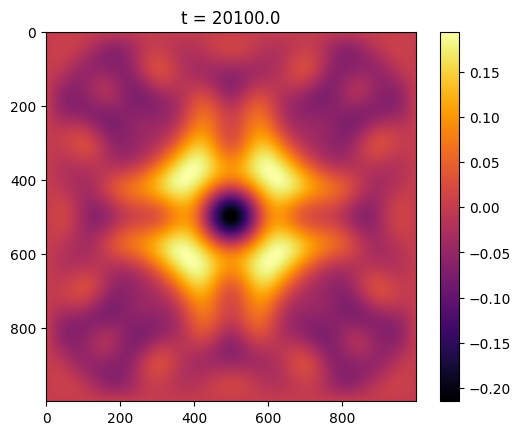

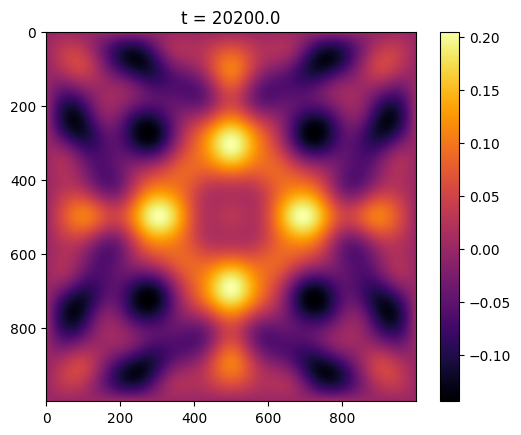

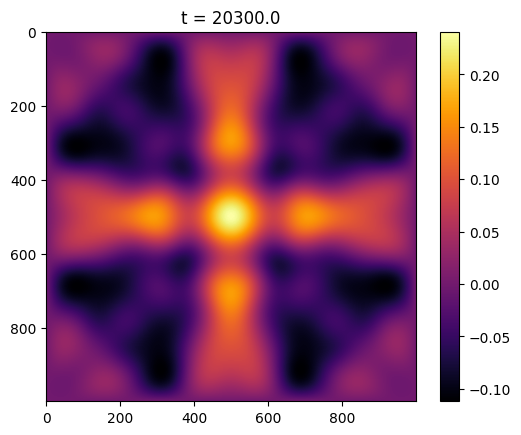

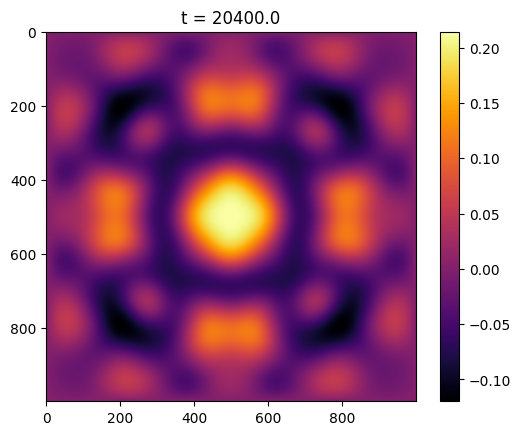

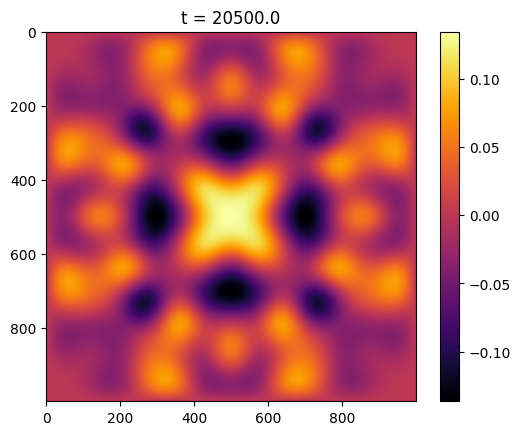

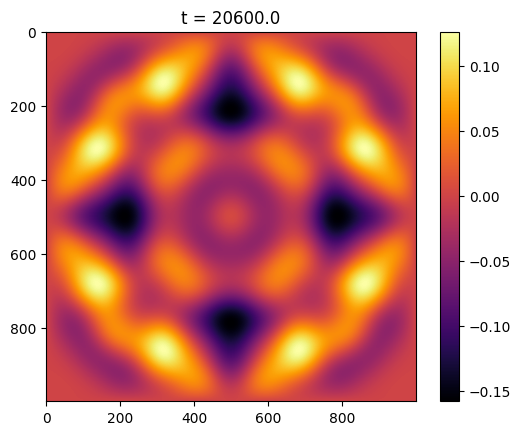

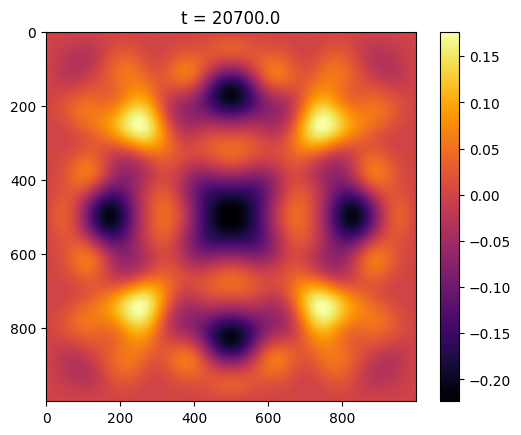

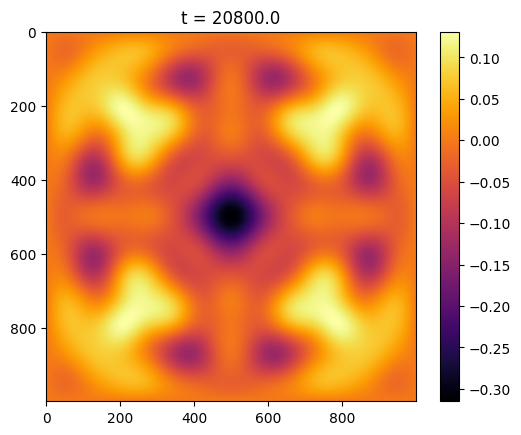

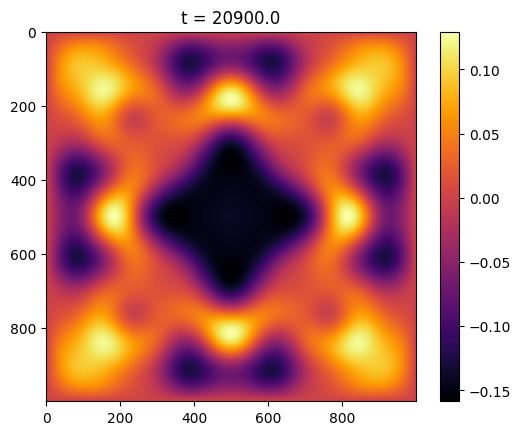

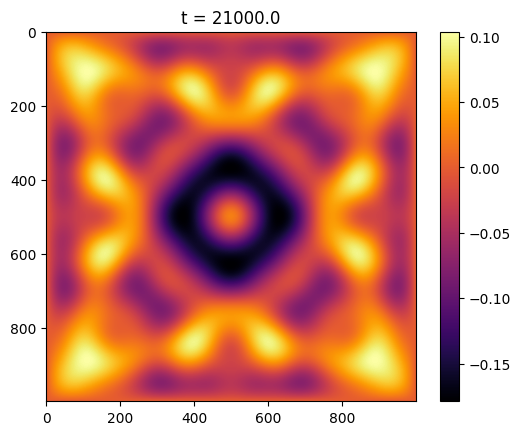

In [49]:
time = 20000*dt1

U2_k = U2_20000.copy()
U2_kprev = U2_20000prev.copy()

for el in range(10):
    for i in range(100):
        U2_k, U2_kprev, time = wave_eq(U2_k, U2_kprev, t=time, dt=dt1)
    plt.imshow(U2_k, cmap = "inferno")
    plt.colorbar()
    plt.title(f"t = {time // dt1}")
    plt.show()

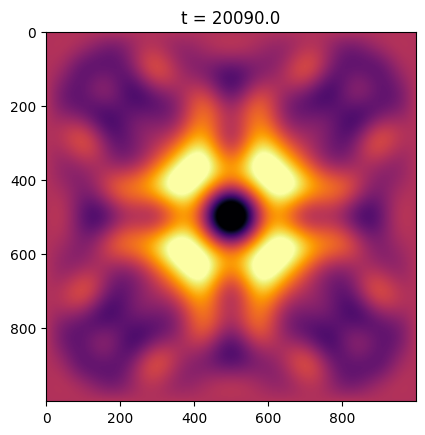

In [50]:
time = 20000*dt1
from matplotlib.animation import FuncAnimation
U2_k = U2_20000.copy()
U2_kprev = U2_20000prev.copy()

fig, ax = plt.subplots()
im = ax.imshow(U2_k, animated= True, cmap="inferno")
title = ax.set_title(f"t = {time//dt1}")

def update(frame):
    global U2_k, U2_kprev, time
    for _ in range(10):
        im.set_array(U2_k)
        title.set_text(f"t = {time//dt1}")
        for _ in range(10):
            U2_k, U2_kprev, time = wave_eq(U2_k, U2_kprev, t=time, dt=dt1)
    return im,
#animatsiooni loomine
ani = FuncAnimation(fig, update, frames=100, repeat=False)


In [51]:

# Save animation as a file
ani.save("wave_simulation.mp4", writer="ffmpeg", fps=5)

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

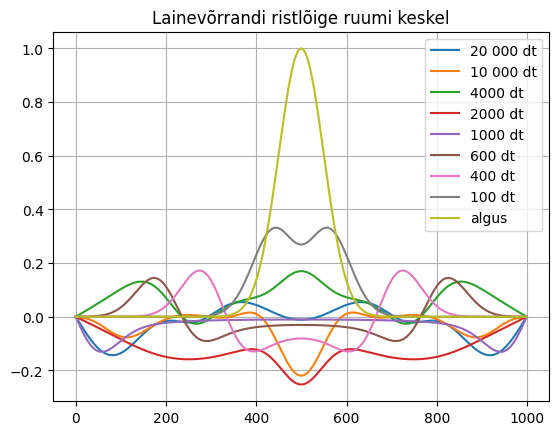

In [52]:
plt.title("Lainevõrrandi ristlõige ruumi keskel")
plt.plot(U2_20000[n//2], label = "20 000 dt")
plt.plot(U2_10000[n//2], label = "10 000 dt")
plt.plot(U2_4000[n//2], label = "4000 dt")
plt.plot(U2_2000[n//2], label = "2000 dt")
plt.plot(U2_1000[n//2], label = "1000 dt")
plt.plot(U2_600[n//2], label = "600 dt")
plt.plot(U2_400[n//2], label = "400 dt")
plt.plot(U2_100[n//2], label = "100 dt")
plt.plot(U2_0[n//2], label = "algus")
plt.grid()
plt.legend()
plt.show()

**LAHENDITE EBATÄPSUSEST TULENEVA ENERGIAKAO HINNANG**\
Pideva lainesüsteemi energia avaldub kujul (https://math.stackexchange.com/questions/1674485/ ):
$$
E(t) = K(t) + P(t),
$$
kus kineetiline energia on võrdeline suurusega
$$K(t) = \frac{1}{2} \int_{R} \left( \frac{\partial u}{\partial t} \right)^2 \, dx \, dy$$
ja potentsiaalne energia on
$$
P(t) = \frac{c^2}{2} \int_{R} \left( \left( \frac{\partial u}{\partial x} \right)^2 + \left( \frac{\partial u}{\partial y} \right)^2 \right) \, dx \, dy.
$$

(kuna see on defineeritud mehaanilisele lainele, siis ilmselt on vaja mingid sobivad kordajad leida et tegu oleks energiaga või energiaga võrdeliste suurustega...)

In [53]:
#TODO

**III ÜLESANNE: FORSSEERITUD LAINEVÕRRAND**

Lainevõrrandi süsteemis
$$
\begin{align}
    &\text{PDE:}\quad \frac{\partial^2 u}{\partial t^2} = c^2(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}) + f(x, y, t), \quad (x, y) \in R,\quad t \in [0, \infty),\quad  c = 3e8, \\
    &f(x, y, t) = \delta_\text{tsenter}\phi(t) ,\quad t \in[0, T], \\
    &\delta_\text{tsenter} = \begin{cases}
    1, & \text{kui}\quad x = 0.5 \;\text{ja} \; y = 0.5 \\
    0 & \text{kõigi teiste koordinaatide puhul.}
    \end{cases}\\
    &\text{BC:} \quad u(x, y, t) = 0,\quad (x, y) \in \partial R, \\
    &\text{IC:} \quad u(x, y, 0) = 0, \quad (x, y) \in R \\
\end{align}
$$
siin mõjub forsseeriva funktsioonina Gaussi pulss $\phi(t)$ aja $t \in [0, T]$ vältel ühele punktile ruumi keskel. Moduleeritud Gaussi pulsi funktsioon avaldub kujul:
$$\phi(t) = A \exp(-[(t - t_0)/\tau]^2) sin(2 \pi f(t - t_0)).$$
Selle funktsiooni kõige olulisem parameeter on sagedus $f$. Teatavasti $ f = c/\lambda$. Alljägrnevas simulatsioonis kasutan sellist Gaussi pulssi, mille Fourier sagedusesituses on sagedusvahemik ruumi mõõtu lainepikkuse järgi defineeritud kui $f \in [c/1, c/0.1]$. Kasutan `scipy.signal` funktsiooni `gausspulse` Gaussi pulsi rakendamisel koodis (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.gausspulse.html ).


In [54]:
f_min = c / 1.0 
f_max = c / 0.1
f_center = (f_min + f_max) / 2

"{:.2e}".format(f_min), "{:.2e}".format(f_max ), "{:.2e}".format(f_center)

('3.00e+08', '3.00e+09', '1.65e+09')

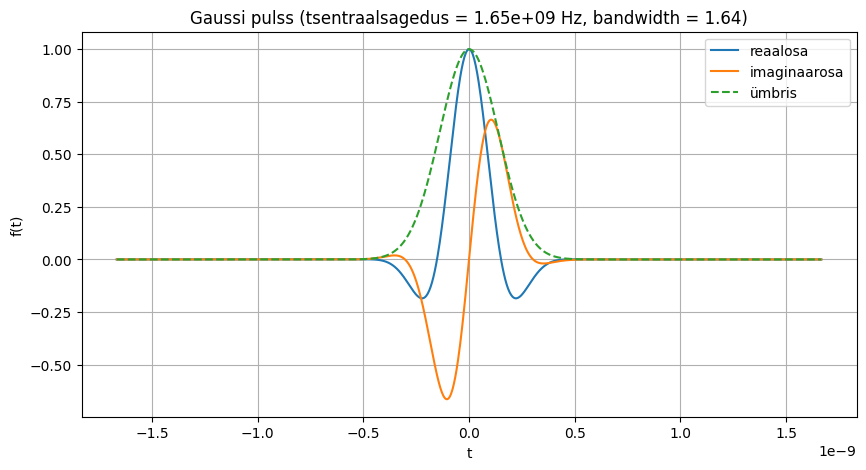

In [55]:
from scipy.signal import gausspulse

bandwidth = (f_max - f_min) / f_center

T = 0.5/c
t = jnp.linspace(-T, T, 1000) 

signal, r1, r2 = gausspulse(t, fc=f_center, bw=bandwidth, retquad=True, retenv=True)

plt.figure(figsize=(10, 5))
plt.plot(t, signal, label = "reaalosa")
plt.plot(t, r1, label = "imaginaarosa")
plt.plot(t, r2,  "--", label = "ümbris")
plt.title(f"Gaussi pulss (tsentraalsagedus = {f_center:.2e} Hz, bandwidth = {bandwidth:.2f})")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid()
plt.show()


In [56]:
len(signal)

1000

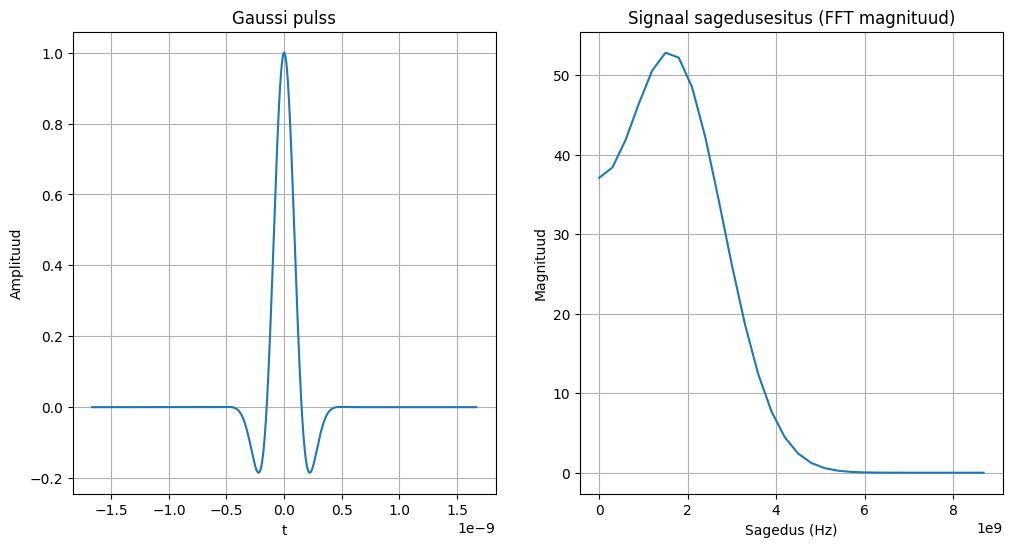

Array(1.7982031e+09, dtype=float32)

In [57]:
#kastuan tavalist numpy-d fft-de arvutamisel, sest jax.numpy annab kahtlase väljundi
import numpy as np
signal_fft = np.fft.fft(signal)

n_signal = len(signal)
sample_rate = 1 / (t[1] - t[0])  # Sampling rate
freq = np.fft.fftfreq(n_signal, d=(t[1] - t[0]))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t, signal)
plt.title("Gaussi pulss")
plt.xlabel("t")
plt.ylabel("Amplituud")
plt.grid()

plt.subplot(1, 2, 2)
valik1 = 970
plt.plot(freq[:n_signal - valik1], np.abs(signal_fft)[:n_signal - valik1])
plt.title("Signaal sagedusesitus (FFT magnituud)")
plt.xlabel("Sagedus (Hz)")
plt.ylabel("Magnituud")
plt.grid()
plt.show()

freq[np.argmax(signal_fft)]

palju küsimusi seoses selle gaussi pulsiga

kasutan hetkel ajavahemikku t-t0 kus graafiku järgi olen t0 väärtuseks määranud 0.5e-9

**III ülesande lahendi funktsiooni defineerimine koodis**

Kuna tekitatud laine puhul hakkab laine levima äärte poole, siis arvan, et oleks mõistlik rajatingimused siiski igas iteratsioonisammus forsseerida.

In [58]:
#funktsioonid III jaoks
def gauss_force(t, A = 10, fc = f_center, bandwidth = bandwidth, t0 = 0.5e-9):
    return gausspulse(t-t0, fc=fc, bw=bandwidth)

def wave_forced_eq(U, U_prev, t, xy_center, dt, forcing_func = gauss_force):
    xc, yc = xy_center
    #rakendan forsseerivat funktsiooni
    U_next = c**2 * dt1**2 * D2(U) + 2*U - U_prev
    U_next = U_next.at[yc, xc].set(U_next[yc, xc] + forcing_func(t))
    t += dt
    
    #rajatingimused
    if(t>0.49/c):
        U_next = U_next.at[0, :].set(jnp.zeros(n))
        U_next = U_next.at[-1, :].set(jnp.zeros(n))
        U_next = U_next.at[:,0].set(jnp.zeros(n))
        U_next = U_next.at[:,-1].set(jnp.zeros(n))
    return U_next, U, t

In [59]:
U3 = jnp.zeros((n, n)) # n = 1000
time3 = 0
U3.shape, time3

((1000, 1000), 0)

In [60]:
U3_0 = U3.copy()
U3_0prev = U3.copy()

U3_1, U3_1prev, time3 = wave_forced_eq(U3_0, U3_0prev, t = time3, xy_center=(500, 500), dt=dt1)

In [61]:
U3_1.max()

Array(0.00067586, dtype=float32)

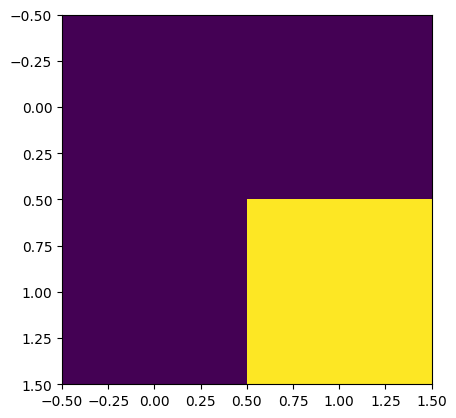

In [62]:
plt.imshow(U3_1[n//2-1: n//2+1,n//2-1: n//2+1])

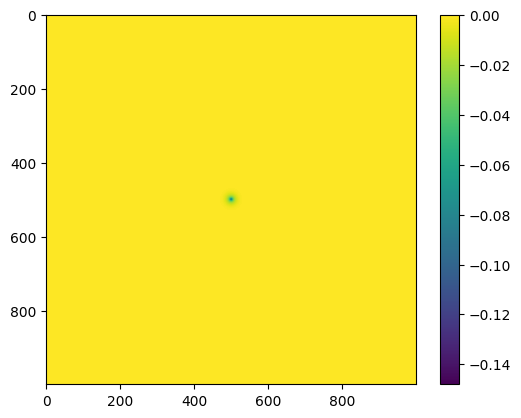

In [66]:
U3_k = U3_1.copy()
U3_kprev = U3_0prev.copy()
for i in range(100):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.colorbar()
plt.show()

In [63]:
time3//dt1

Array(1., dtype=float32)

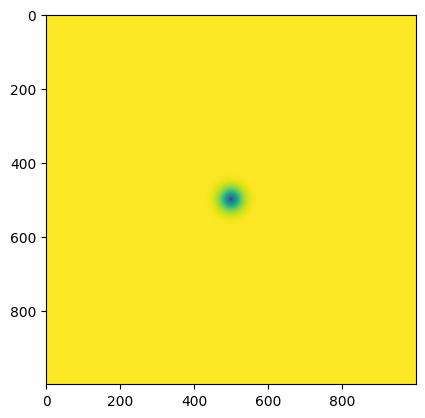

In [67]:
for i in range(100):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)

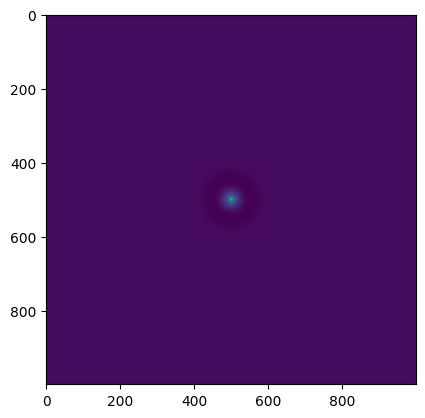

In [68]:
for i in range(100):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)

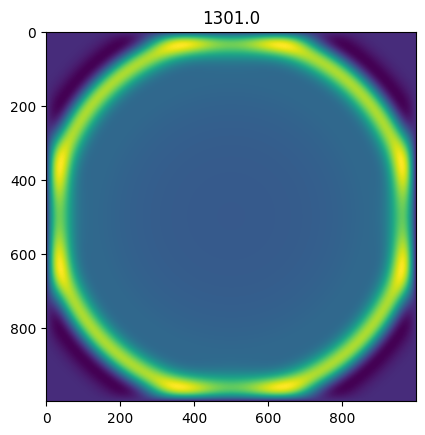

In [69]:
for i in range(1000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.show()

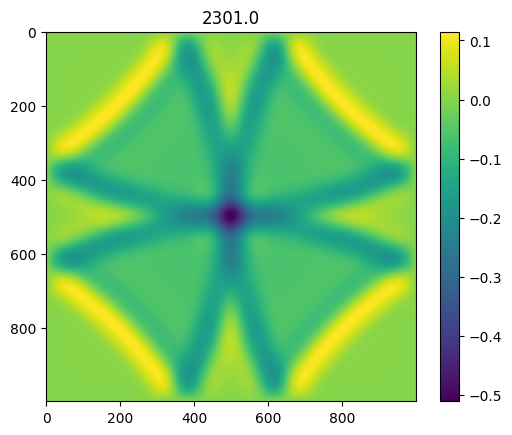

In [70]:
for i in range(1000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

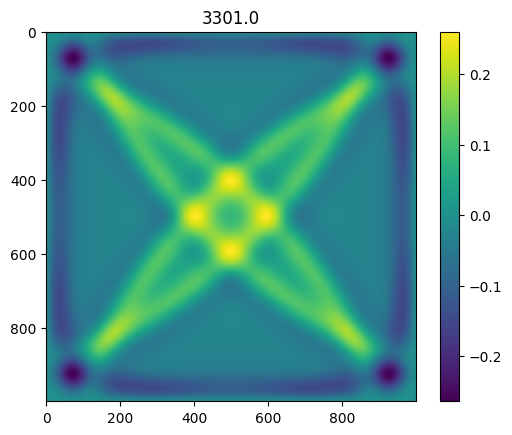

In [71]:
for i in range(1000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

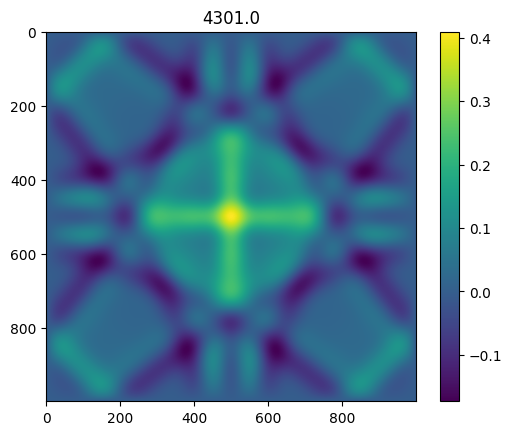

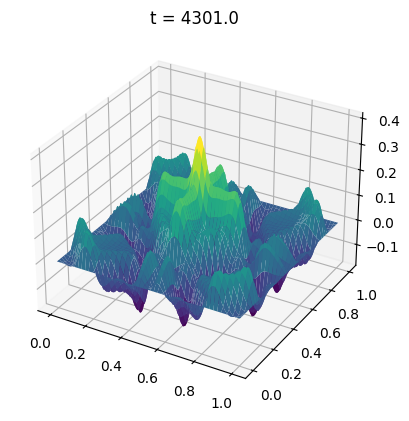

In [72]:
for i in range(1000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U3_k, cmap="viridis")
plt.title(f"t = {time3//dt1}")
plt.show()

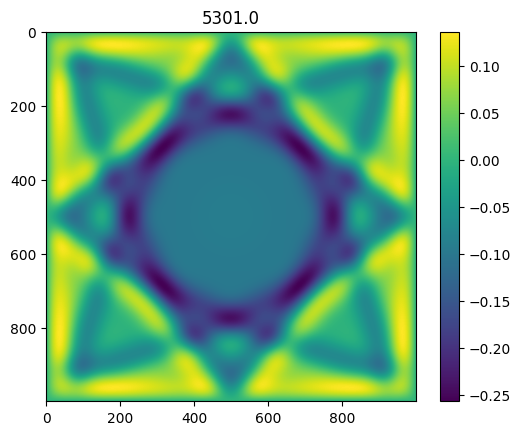

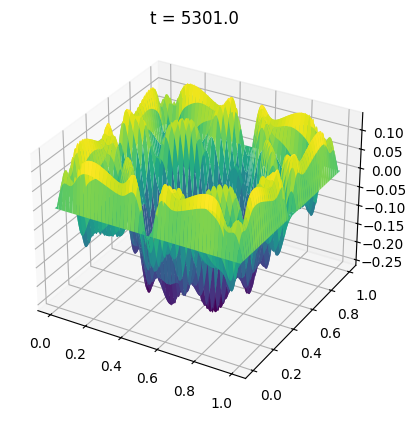

In [73]:
for i in range(1000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U3_k, cmap="viridis")
plt.title(f"t = {time3//dt1}")
plt.show()

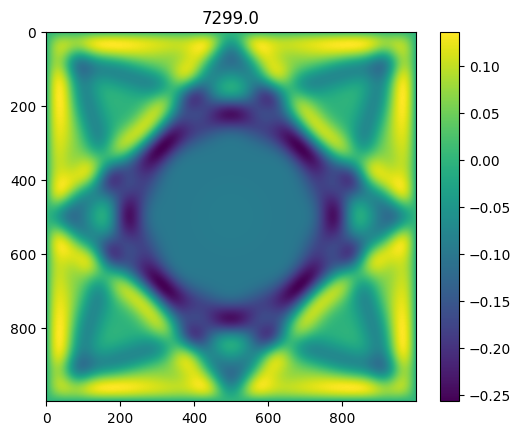

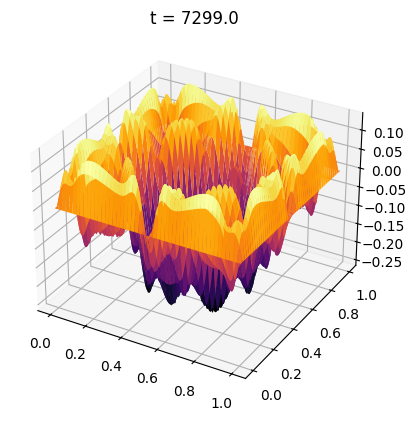

In [74]:
time3 = 6300*dt1
U3_k_uus, U3_kprev_uus = U3_k.copy(), U3_kprev.copy()
data_matrix1 = []
data_matrix1.append(U3_k_uus)
for i in range(1000):
    U3_k_uus, U3_kprev_uus, time3 = wave_forced_eq(U3_k_uus, U3_kprev_uus, t = time3, xy_center=(500, 500), dt=dt1)
    data_matrix1.append(U3_k_uus)

plt.imshow(U3_k)
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U3_k, cmap="inferno")
plt.title(f"t = {time3//dt1}")
plt.show()


In [75]:
data_matrix1 = np.array(data_matrix1)

In [76]:
data_matrix1.shape

(1001, 1000, 1000)

In [77]:
data_matrix1.nbytes

4004000000

In [78]:
np.save("2DFDTD_forced_wave_t0=6300_dt=1000_.npy", data_matrix1)

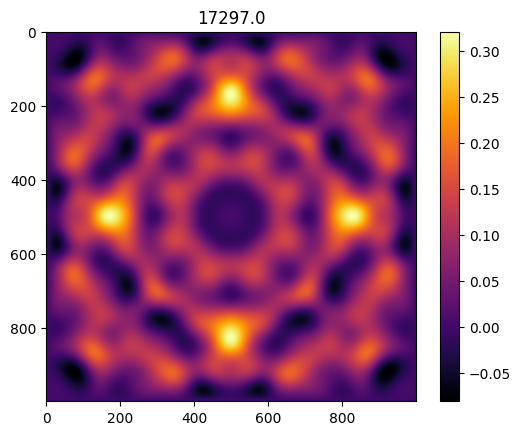

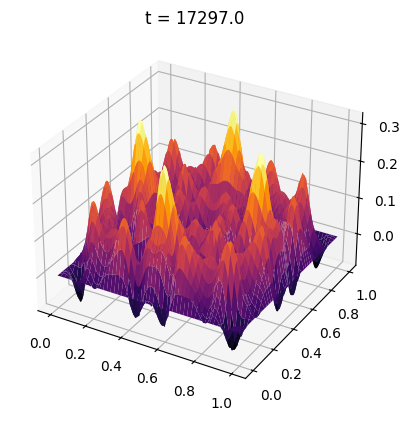

In [76]:
for i in range(10000):
    U3_k, U3_kprev, time3 = wave_forced_eq(U3_k, U3_kprev, t = time3, xy_center=(500, 500), dt=dt1)

plt.imshow(U3_k, cmap="inferno")
plt.title(f"{time3//dt1}")
plt.colorbar()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xv, yv, U3_k, cmap="inferno")
plt.title(f"t = {time3//dt1}")
plt.show()

In [223]:
#TODO: IV ÜLESANNE